In [5]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import defaultdict
from matplotlib.patches import Patch
import pandas as pd
from typing import Union

from cinnabar import plotting
from cinnabar.compare import compare_and_rank_results

from openfe_benchmarks.results._benchmark_results import get_benchmark_results

## Load Calculated Data

In [2]:
submission_ids = {
    "Sage 2.3.0 (ff14SB) TIP3P": "2026-02-12_sage_230_jacs_set",
    "Sage 2.3.0 (ff14SB) OPC3": "2026-09-03_openff-2.3.0_opc3_jacs_set",
    r"Sage 3.0.0-$\alpha_0$ OPC3": "2026-08-05_openff-3.0.0-alpha0_opc3_jacs",
    r"Sage 3.0.0-$\alpha_{1b}$ OPC3": "2026-08-04-openff3.0.0-alpha1b_opc3-jacs",
}

results = {key: get_benchmark_results(sub_id) for key, sub_id in submission_ids.items()}
for name, result in results.items():
    result.ddg_femaps(
        source=name
    )  # first run will create and cache the result for future calls
    result.dg_femaps(
        source=name
    )  # first run will create and cache the result for future calls

2026-09-04 09:44:14 - openfe_benchmarks.results._benchmark_results - INFO - Computing FEMaps for ddg results - first access may be slow
2026-09-04 09:44:14 - openfe_benchmarks.data._benchmark_systems - INFO - Loaded system 'jnk1' from benchmark set 'jacs_set' with:
  5 ligand file(s), and 0 cofactor file(s).
  Found protein file: True.
  Found 1 ligand network files with keys: industry_benchmarks_network
2026-09-04 09:44:14 - openfe_benchmarks.data._benchmark_systems - INFO - Loaded system 'thrombin' from benchmark set 'jacs_set' with:
  5 ligand file(s), and 0 cofactor file(s).
  Found protein file: True.
  Found 1 ligand network files with keys: industry_benchmarks_network
2026-09-04 09:44:14 - openfe_benchmarks.data._benchmark_systems - INFO - Loaded system 'cdk2' from benchmark set 'jacs_set' with:
  5 ligand file(s), and 0 cofactor file(s).
  Found protein file: True.
  Found 1 ligand network files with keys: industry_benchmarks_network
2026-09-04 09:44:14 - openfe_benchmarks.data

Now `results` contains `BenchmarkResults` for each system and those results can be plotted with `cinnebar` by accessing the `femap` available through `results[key].ddg_femaps()` or `results[key].dg_femaps()`. See [cinnebar documentation](https://cinnabar.openfree.energy/en/latest/tutorials/cinnabar-api.html#applying-an-experimental-shift) for more information on how to plot.

## Create Pair Plots

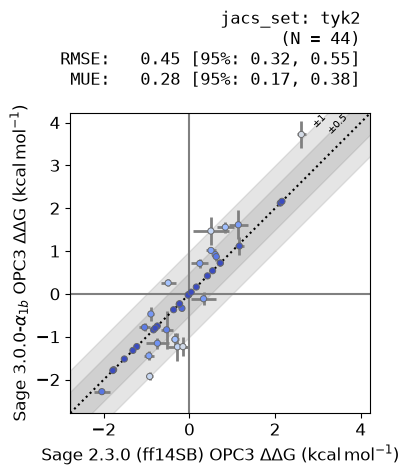

In [3]:
key1, key2 = "Sage 2.3.0 (ff14SB) OPC3", r"Sage 3.0.0-$\alpha_{1b}$ OPC3"
system_group_name = ("jacs_set", "tyk2")

df_sage_2_1_1 = results[key1].ddg_femaps()[system_group_name].get_relative_dataframe()
df_sage_2_3_0 = results[key2].ddg_femaps()[system_group_name].get_relative_dataframe()

# use numpy arrays with pair_plot
plotting.pair_plot(
    x=df_sage_2_1_1["DDG (kcal/mol)"].to_numpy(),  # provide the x values for the plot
    y=df_sage_2_3_0["DDG (kcal/mol)"].to_numpy(),  # provide the y values for the plot
    xerr=df_sage_2_1_1[
        "uncertainty (kcal/mol)"
    ].to_numpy(),  # provide the x error values for the plot
    yerr=df_sage_2_3_0[
        "uncertainty (kcal/mol)"
    ].to_numpy(),  # provide the y error values for the plot
    title=f"{system_group_name[0]}: {system_group_name[1]}",
    xlabel=key1,  # match the x and y labels to the values being plotted
    ylabel=key2,
    figsize=5,
    statistics=[
        "RMSE",
        "MUE",
    ],  # add RMSE and MUE to the plot along with the confidence intervals from bootstrapping
);

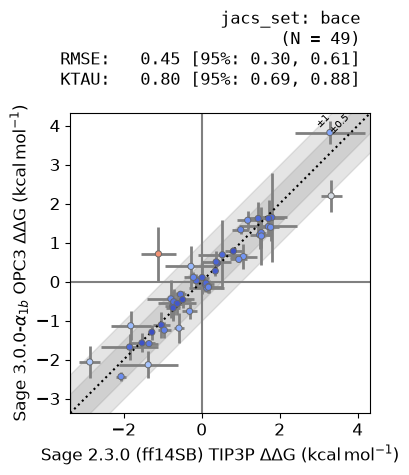

In [4]:

key1, key2 = "Sage 2.3.0 (ff14SB) TIP3P", r"Sage 3.0.0-$\alpha_{1b}$ OPC3"
system_group_name = ("jacs_set", "bace")

df_sage_2_1_1 = results[key1].ddg_femaps()[system_group_name].get_relative_dataframe()
df_sage_2_3_0 = results[key2].ddg_femaps()[system_group_name].get_relative_dataframe()

# Restrict to model predictions only (exclude overlapping experimental rows)
df_sage_2_1_1 = df_sage_2_1_1[df_sage_2_1_1["computational"]].copy()
df_sage_2_3_0 = df_sage_2_3_0[df_sage_2_3_0["computational"]].copy()

# use numpy arrays with pair_plot
plotting.pair_plot(
    x=df_sage_2_1_1["DDG (kcal/mol)"].to_numpy(),  # provide the x values for the plot
    y=df_sage_2_3_0["DDG (kcal/mol)"].to_numpy(),  # provide the y values for the plot
    xerr=df_sage_2_1_1[
        "uncertainty (kcal/mol)"
    ].to_numpy(),  # provide the x error values for the plot
    yerr=df_sage_2_3_0[
        "uncertainty (kcal/mol)"
    ].to_numpy(),  # provide the y error values for the plot
    title=f"{system_group_name[0]}: {system_group_name[1]}",
    xlabel=key1,  # match the x and y labels to the values being plotted
    ylabel=key2,
    figsize=5,
    statistics=[
        "RMSE",
        "KTAU",
    ],  # add RMSE and MUE to the plot along with the confidence intervals from bootstrapping
);

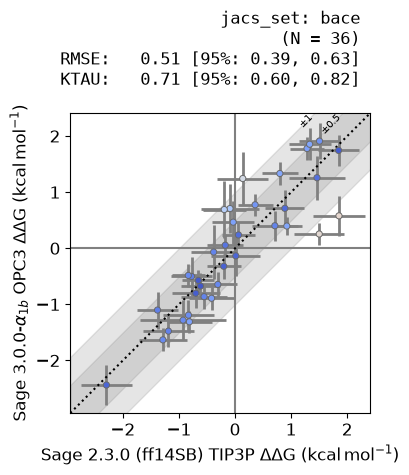

In [5]:

key1, key2 = "Sage 2.3.0 (ff14SB) TIP3P", r"Sage 3.0.0-$\alpha_{1b}$ OPC3"
system_group_name = ("jacs_set", "bace")

df_sage_2_1_1 = results[key1].dg_femaps()[system_group_name].get_absolute_dataframe()
df_sage_2_3_0 = results[key2].dg_femaps()[system_group_name].get_absolute_dataframe()

# Restrict to model predictions only (exclude overlapping experimental rows)
df_sage_2_1_1 = df_sage_2_1_1[df_sage_2_1_1["computational"]].copy()
df_sage_2_3_0 = df_sage_2_3_0[df_sage_2_3_0["computational"]].copy()

# use numpy arrays with pair_plot
plotting.pair_plot(
    x=df_sage_2_1_1["DG (kcal/mol)"].to_numpy(),  # provide the x values for the plot
    y=df_sage_2_3_0["DG (kcal/mol)"].to_numpy(),  # provide the y values for the plot
    xerr=df_sage_2_1_1[
        "uncertainty (kcal/mol)"
    ].to_numpy(),  # provide the x error values for the plot
    yerr=df_sage_2_3_0[
        "uncertainty (kcal/mol)"
    ].to_numpy(),  # provide the y error values for the plot
    title=f"{system_group_name[0]}: {system_group_name[1]}",
    xlabel=key1,  # match the x and y labels to the values being plotted
    ylabel=key2,
    figsize=5,
    statistics=[
        "RMSE",
        "KTAU",
    ],  # add RMSE and MUE to the plot along with the confidence intervals from bootstrapping
);

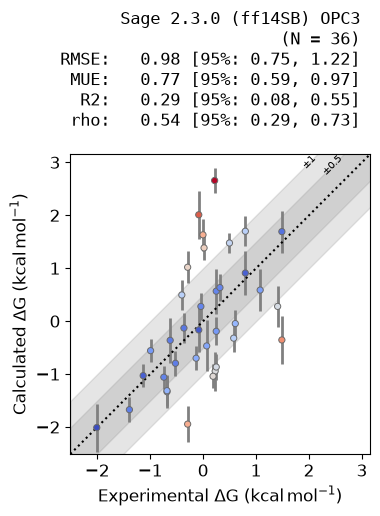

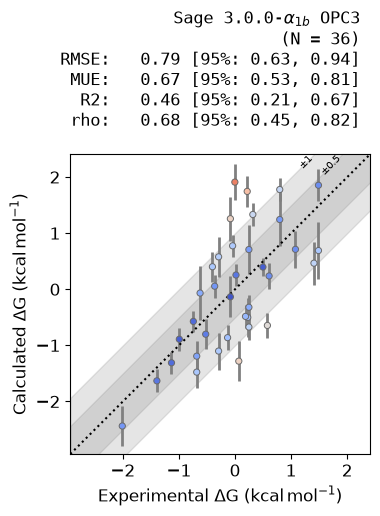

In [6]:
system_group_name = ("jacs_set", "bace")

key = "Sage 2.3.0 (ff14SB) OPC3"
plotting.plot_DGs(
    results[key].dg_femaps()[system_group_name],
    source=key,  # Use the default submission_id
    title=key,
    figsize=5,
    scatter_kwargs={"s": 20, "marker": "o"},
)
key = r"Sage 3.0.0-$\alpha_{1b}$ OPC3"
plotting.plot_DGs(
    results[key].dg_femaps()[system_group_name],
    source=key,  # Use the default submission_id
    title=key,
    figsize=5,
    scatter_kwargs={"s": 20, "marker": "o"},
)

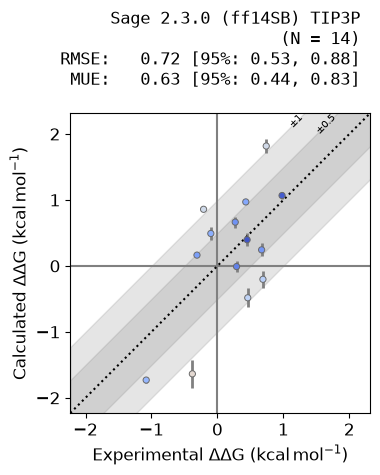

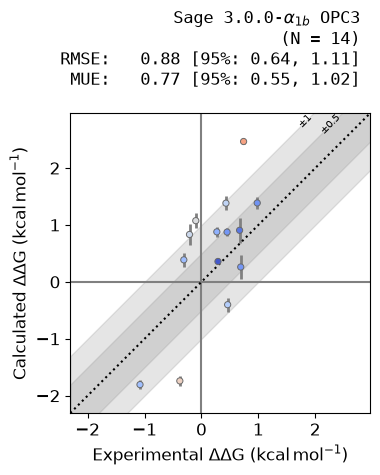

In [7]:
system_group_name = ("jacs_set", "thrombin")

key = "Sage 2.3.0 (ff14SB) TIP3P"
plotting.plot_DDGs(
    results[key].ddg_femaps()[system_group_name],
    source=key,  # Use the default submission_id
    title=key,
    figsize=5,
    scatter_kwargs={"s": 20, "marker": "o"},
)
key = r"Sage 3.0.0-$\alpha_{1b}$ OPC3"
plotting.plot_DDGs(
    results[key].ddg_femaps()[system_group_name],
    source=key,  # Use the default submission_id
    title=key,
    figsize=5,
    scatter_kwargs={"s": 20, "marker": "o"},
)

## Compare Performance in Benchmark Systems

### Empirical Cumulative Distribution Function (ECDF) Plots

See [cinnebar documentation](https://cinnabar.openfree.energy/en/latest/tutorials/ecdf-plots.html) for more details

In [8]:
# Combining FEMaps
system_group_name = ("jacs_set", "bace")

femap_list = [result.ddg_femaps()[system_group_name] for result in results.values()]
combined_femap = sum(femap_list[1:], femap_list[0])

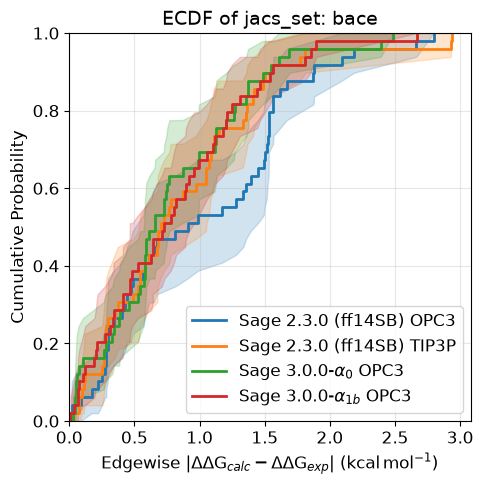

In [9]:
fig = plotting.ecdf_plot_DDGs(
    combined_femap,
    title=f"ECDF of {system_group_name[0]}: {system_group_name[1]}",
    #    sources=["Method A", "Method B"], # narrow down sources
    #    labels=["Pipeline A", "Pipeline B"], # set custom labels
    figsize=5,
    #    nbootstraps=0,  # optionally turn off uncertainty intervals
)

In [10]:
def get_ecdf_intercepts(
    combined_femap,
    x_values: Union[list[float], np.ndarray],
    sources: list[str] = None,
) -> pd.DataFrame:
    """
    Get ECDF y-intercepts for each source at specified x-axis values.

    This function properly aligns computational and experimental data by joining
    on (labelA, labelB) edge identifiers before computing errors. This ensures
    that errors are computed for matching edges, not just row-by-row.

    Parameters
    ----------
    combined_femap : cinnabar.femap.FEMap
        Combined FEMap object containing multiple sources
    x_values : list or array
        X-axis values (error thresholds in kcal/mol) at which to compute ECDF intercepts
    sources : list of str, optional
        List of sources to include. If None, uses all sources in the FEMap.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns for each source and rows for each x-value.
        Values are the cumulative probability (fraction of errors <= x-value).

    Examples
    --------
    >>> # Assume combined_femap is created as in examples/5_*.ipynb
    >>> x_vals = [0.5, 1.0, 1.5, 2.0]
    >>> df = get_ecdf_intercepts(combined_femap, x_vals)
    >>> print(df)
    """
    x_values = np.array(x_values)

    # Get all data from the FEMap
    ddg_df = combined_femap.get_relative_dataframe()

    # Filter to computational rows only
    ddg_comp = ddg_df[ddg_df["computational"]]
    ddg_exp = ddg_df[~ddg_df["computational"]]

    # Get all sources if not specified
    if sources is None:
        sources = ddg_comp["source"].unique()

    # Dictionary to store ECDF intercepts for each source
    intercepts = {}

    for source in sources:
        # Filter to this source - computational only
        source_comp = ddg_comp[ddg_comp["source"] == source].copy()

        # Join on (labelA, labelB) to ensure proper alignment
        # This is the SAFE pattern - pandas will align the data by the edge labels
        comp_indexed = source_comp.set_index(["labelA", "labelB"])
        exp_indexed = ddg_exp.set_index(["labelA", "labelB"])

        # Inner join: only edges with both computational and experimental
        joined = comp_indexed.join(
            exp_indexed, how="inner", lsuffix="_comp", rsuffix="_exp"
        )

        if joined.empty:
            # No overlapping edges for this source
            ecdf_values = np.zeros_like(x_values, dtype=float)
            intercepts[source] = ecdf_values.tolist()
            continue

        # Now the rows are aligned - safe to subtract
        # Column names after join: "DDG (kcal/mol)_comp" and "DDG (kcal/mol)_exp"
        abs_errors = np.abs(
            joined["DDG (kcal/mol)_comp"].values - joined["DDG (kcal/mol)_exp"].values
        )

        # Compute ECDF values at specified x-values
        # Following cinnabar.plotting.ecdf_plot approach:
        # ECDF at x is the fraction of errors <= x
        sorted_errors = np.sort(abs_errors)
        n = len(sorted_errors)

        # Use searchsorted to find the fraction of errors <= each x-value
        # side='right' means errors equal to x are counted as <= x
        ecdf_values = np.searchsorted(sorted_errors, x_values, side="right") / n

        intercepts[source] = ecdf_values.tolist()

    # Create DataFrame with x_values as index
    result_df = pd.DataFrame(intercepts, index=x_values)
    result_df.index.name = "x_value (kcal/mol)"

    return result_df

In [11]:
x_values = [0.5, 1.0, 1.5, 2.0]
df_intercept = get_ecdf_intercepts(combined_femap, x_values)
df_intercept

,Sage 2.3.0 (ff14SB) OPC3,Sage 2.3.0 (ff14SB) TIP3P,Sage 3.0.0-$\alpha_0$ OPC3,Sage 3.0.0-$\alpha_{1b}$ OPC3
x_value (kcal/mol),,,,
0.5,0.367347,0.326531,0.306122,0.387755
1.0,0.530612,0.612245,0.693878,0.673469
1.5,0.693878,0.877551,0.897959,0.877551
2.0,0.918367,0.959184,0.959184,0.979592


In [12]:
def plot_ecdf_with_intercepts(combined_femap, x_values, title=None, figsize=5):
    fig = plotting.ecdf_plot_DDGs(
        combined_femap,
        title=title,
        figsize=figsize,
    )
    df_intercept = get_ecdf_intercepts(combined_femap, x_values)
    sources = list(df_intercept.columns)

    # Get the axes from the figure
    ax = fig.gca()

    # Extract colors from the plotted lines by matching labels
    line_colors = {}
    for line in ax.get_lines():
        label = line.get_label()
        # Skip lines without labels (like grid lines)
        if label and not label.startswith("_"):
            color = line.get_color()
            line_colors[label] = color

    for xvalue in x_values:
        df_tmp = df_intercept[df_intercept.index == xvalue]

        # Black vertical reference line
        max_y = np.max(df_tmp.to_numpy())
        ax.plot(
            [xvalue, xvalue], [0, max_y], color="black", linewidth=0.8, linestyle="-"
        )

        # Draw thin dashed horizontal lines for each source at the intercept
        for source in sources:
            y_intercept = df_intercept.loc[xvalue, source]
            # Use color from the plotted line if available, else use black
            color = line_colors.get(source, "black")
            ax.plot(
                [0, xvalue],
                [y_intercept, y_intercept],
                color=color,
                linewidth=0.8,
                linestyle="--",
            )

    return fig

def plot_ecdf_with_intercepts_and_difference(combined_femap, x_values, title=None, figsize=5, reference_model="Sage 2.3.0 (ff14SB) TIP3P"):
    """
    Plot ECDF with intercepts and difference curves relative to a reference model.
    
    Creates two subplots: 
    1. ECDF plot with intercept lines
    2. Difference curves showing how other models differ from the reference
    
    Parameters
    ----------
    combined_femap : cinnabar.femap.FEMap
        Combined FEMap object containing multiple sources
    x_values : list or array
        X-axis values (error thresholds in kcal/mol) at which to compute ECDF intercepts
    title : str, optional
        Title for the plot
    figsize : float or tuple, optional
        Figure size (width of each subplot)
    reference_model : str, optional
        Name of the reference model for computing differences
        
    Returns
    -------
    fig : matplotlib.figure.Figure
        Figure with two subplots
    """
    # Get the intercepts
    df_intercept = get_ecdf_intercepts(combined_femap, x_values)
    sources = list(df_intercept.columns)
    
    # Validate reference model
    if reference_model not in sources:
        raise ValueError(f"Reference model '{reference_model}' not found in sources: {sources}")
    
    # Create figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(figsize * 2, figsize))
    
    # ===== SUBPLOT 1: ECDF with Intercepts =====
    # Plot the ECDF lines on ax1
    ecdf_fig = plotting.ecdf_plot_DDGs(
        combined_femap,
        title=title,
        figsize=figsize,
        nbootstraps=2000,  # optionally turn off uncertainty intervals
    )
    ecdf_ax = ecdf_fig.gca()
    
    # Copy lines and styling from temporary ECDF figure
    line_colors = {}
    line_data = {}  # Store original line data for later use
    for line in ecdf_ax.get_lines():
        label = line.get_label()
        if label and not label.startswith("_"):
            ax1.plot(line.get_xdata(), line.get_ydata(), 
                    color=line.get_color(), linewidth=line.get_linewidth(),
                    label=label)
            line_colors[label] = line.get_color()
            line_data[label] = (line.get_xdata(), line.get_ydata())
    
    # Copy axis labels and styling
    ax1.set_xlabel(ecdf_ax.get_xlabel())
    ax1.set_ylabel(ecdf_ax.get_ylabel())
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    plt.close(ecdf_fig)
    
    # Draw intercept lines on ax1
    for xvalue in x_values:
        df_tmp = df_intercept[df_intercept.index == xvalue]
        max_y = np.max(df_tmp.to_numpy())
        ax1.plot([xvalue, xvalue], [0, max_y], color="black", linewidth=0.8, linestyle="-")
        
        for source in sources:
            y_intercept = df_intercept.loc[xvalue, source]
            color = line_colors.get(source, "black")
            ax1.plot([0, xvalue], [y_intercept, y_intercept],
                    color=color, linewidth=0.8, linestyle="--")
    
    # ===== SUBPLOT 2: Difference Curves =====
    # Plot difference curves for each non-reference model
    if reference_model in line_data:
        ref_x, ref_y = line_data[reference_model]
        
        for source in sources:
            if source == reference_model:
                continue
            
            if source in line_data:
                src_x, src_y = line_data[source]
                
                # Interpolate to common x-axis if needed
                if len(src_x) == len(ref_x) and np.allclose(src_x, ref_x):
                    # Same x-axis, direct subtraction
                    diff_y = src_y - ref_y
                    diff_x = src_x
                else:
                    # Interpolate source to reference x-axis
                    diff_y = np.interp(ref_x, src_x, src_y) - ref_y
                    diff_x = ref_x
                
                color = line_colors.get(source, "black")
                ax2.plot(diff_x, diff_y, color=color, linewidth=2, label=source)
    
    # Add zero line for reference
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    ax2.set_xlabel('Error (kcal/mol)')
    ax2.set_ylabel(f'Difference in ECDF\n(Model - {reference_model})')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    if title:
        fig.suptitle(title, fontsize=14, fontweight="bold")
    
    plt.tight_layout()
    
    return fig

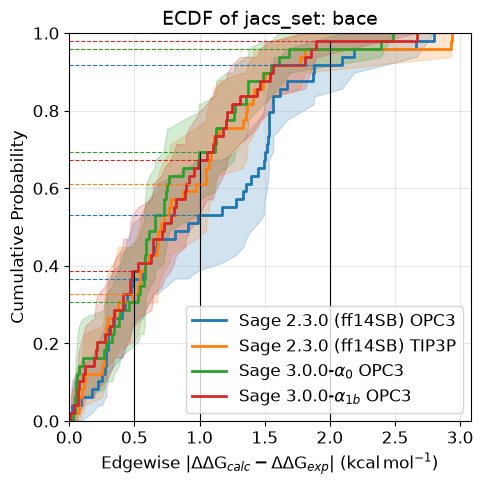

In [13]:
plot_ecdf_with_intercepts(
    combined_femap,
    [0.5, 1.0, 2.0],
    title=f"ECDF of {system_group_name[0]}: {system_group_name[1]}",
);

#### Get All Plots

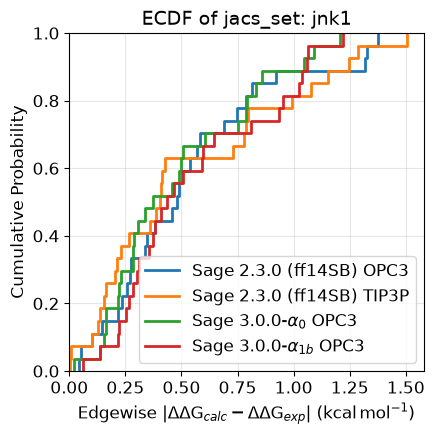

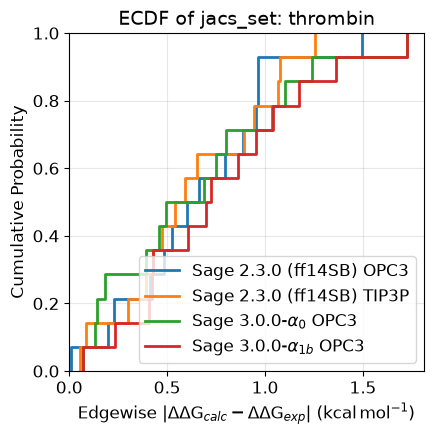

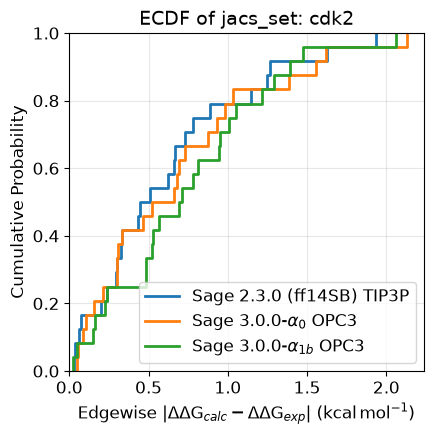

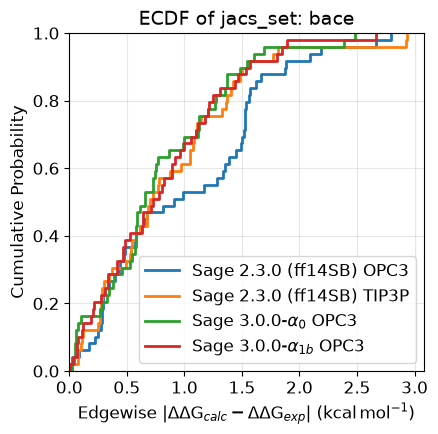

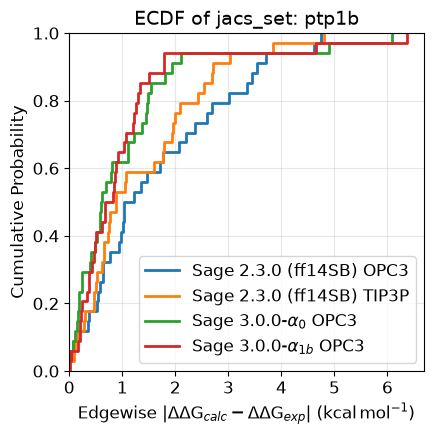

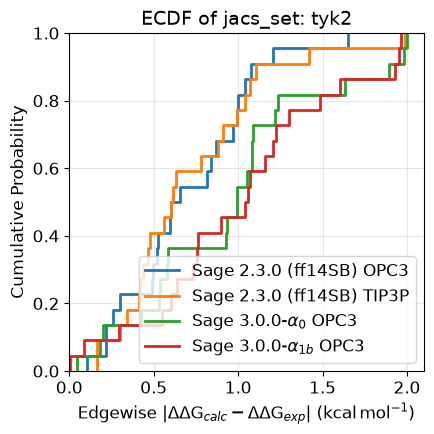

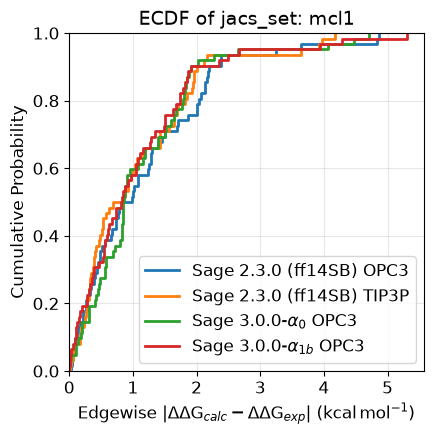

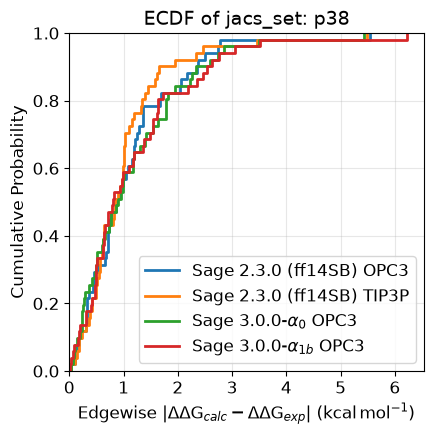

In [14]:
system_keys = next(iter(results.values())).ddg_femaps().keys()
for system_group_name in system_keys:
    femap_list = [result.ddg_femaps()[system_group_name] for result in results.values() if system_group_name in result.ddg_femaps()]
    combined_femap = sum(femap_list[1:], femap_list[0])
    fig = plotting.ecdf_plot_DDGs(
        combined_femap,
        title=f"ECDF of {system_group_name[0]}: {system_group_name[1]}",
        #    sources=["Method A", "Method B"], # narrow down sources
        #    labels=["Pipeline A", "Pipeline B"], # set custom labels
        figsize=4.5,
        nbootstraps=0,  # optionally turn off uncertainty intervals
    )

### Compare and Rank Results

See [cinnebar documentation](https://cinnabar.openfree.energy/en/latest/tutorials/results_comparison.html) for more details.

In [15]:
# Combining FEMaps
system_group_name = ("jacs_set", "bace")

femap_list = [result.ddg_femaps()[system_group_name] for result in results.values()]
combined_femap = sum(femap_list[1:], femap_list[0])

In [16]:
summary_df, comparison_df = compare_and_rank_results(
    femap=combined_femap,
    prediction_type="edgewise",
    rank_metric="MUE",  # the metric used for ranking the results
    metrics_to_compute=["MUE", "RMSE"],  # metrics to report in the summary table
    num_bootstraps=5_000,
    confidence_level=0.95,  # report 95 % confidence intervals
    alpha=0.05,  # for statistical significance testing (e.g. p-value threshold)
)

In [17]:
summary_df

,Model,MUE,MUE_CI_Lower,MUE_CI_Upper,RMSE,RMSE_CI_Lower,RMSE_CI_Upper,CLD
0,Sage 2.3.0 (ff14SB) OPC3,1.007748,0.814056,1.215133,1.231812,1.028836,1.432698,b
1,Sage 2.3.0 (ff14SB) TIP3P,0.853040,0.682652,1.043569,1.071311,0.851107,1.299251,a
2,Sage 3.0.0-$\alpha_0$ OPC3,0.783468,0.627497,0.946172,0.971617,0.790913,1.153355,a
3,Sage 3.0.0-$\alpha_{1b}$ OPC3,0.799819,0.640640,0.965522,0.989507,0.808198,1.166011,a


In [18]:
comparison_df

,Model 1,Model 2,Diff in MUE,CI Lower,CI Upper,p-value,significant,p-value corrected
0,Sage 2.3.0 (ff14SB) OPC3,Sage 2.3.0 (ff14SB) TIP3P,0.154708,0.040172,0.275223,0.0076,True,0.0304
1,Sage 2.3.0 (ff14SB) OPC3,Sage 3.0.0-$\alpha_0$ OPC3,0.224280,0.082957,0.361811,0.0024,True,0.0120
2,Sage 2.3.0 (ff14SB) OPC3,Sage 3.0.0-$\alpha_{1b}$ OPC3,0.207929,0.075183,0.345768,0.0008,True,0.0048
3,Sage 2.3.0 (ff14SB) TIP3P,Sage 3.0.0-$\alpha_0$ OPC3,0.069572,-0.043385,0.175625,0.2168,False,0.6504
4,Sage 2.3.0 (ff14SB) TIP3P,Sage 3.0.0-$\alpha_{1b}$ OPC3,0.053221,-0.046040,0.159468,0.3152,False,0.6504
5,Sage 3.0.0-$\alpha_0$ OPC3,Sage 3.0.0-$\alpha_{1b}$ OPC3,-0.016351,-0.097908,0.070797,0.6756,False,0.6756


In [19]:
def plot_comparison(summary_df, title):
    cinnabar_colors = sns.color_palette(None, n_colors=len(summary_df))

    # Dynamically find all metrics with CI_Lower and CI_Upper
    metrics, seen = [], set()
    for col in summary_df.columns:
        if "_CI_" in col:
            metric_name = col.split("_CI_")[0]
            if metric_name not in seen:
                if (
                    f"{metric_name}_CI_Lower" in summary_df.columns
                    and f"{metric_name}_CI_Upper" in summary_df.columns
                ):
                    metrics.append(
                        (
                            metric_name,
                            [
                                metric_name,
                                f"{metric_name}_CI_Lower",
                                f"{metric_name}_CI_Upper",
                            ],
                        )
                    )
                    seen.add(metric_name)

    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 5))

    # Handle single metric case (axes won't be an array)
    if len(metrics) == 1:
        axes = [axes]

    # Define hatch patterns for unique CLD values
    hatches = ["", "///", "\\\\\\", "xxx", "|||", "---", "+++", "***"]
    unique_clds = summary_df["CLD"].unique()
    cld_hatch_map = {
        cld: hatches[i % len(hatches)] for i, cld in enumerate(unique_clds)
    }

    x = np.arange(len(summary_df))
    width = 0.6

    for ax, (metric_name, columns) in zip(axes, metrics):
        value_col, lower_col, upper_col = columns

        # Draw one bar per row
        for i, (idx, row) in enumerate(summary_df.iterrows()):
            ax.bar(
                i,
                row[value_col],
                width,
                yerr=[
                    [row[value_col] - row[lower_col]],
                    [row[upper_col] - row[value_col]],
                ],
                color=cinnabar_colors[i % len(cinnabar_colors)],
                hatch=cld_hatch_map[row["CLD"]],
                capsize=5,
                error_kw={"elinewidth": 2},
            )

        ax.set_ylabel(metric_name)
        ax.set_xticks(x)
        ax.set_ylim(bottom=0)
        ax.set_xticklabels(summary_df.Model, rotation=45, ha="right")
        ax.grid(axis="y", alpha=0.3)

    fig.suptitle(title, fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
    plt.close()

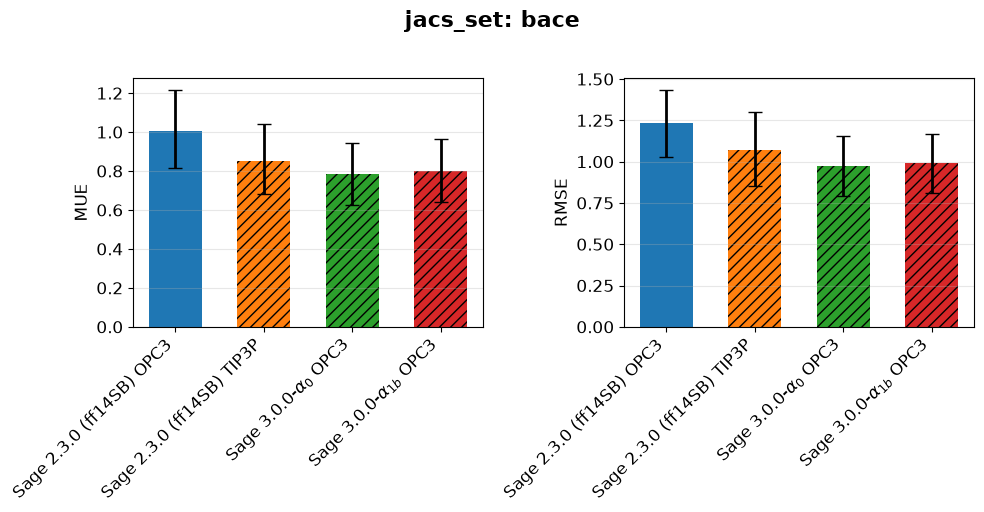

In [20]:
plot_comparison(summary_df, f"{system_group_name[0]}: {system_group_name[1]}")

## Compare All Systems

In [21]:
def get_rmse_for_femap(femap):
    """
    Calculate RMSE and MUE for a single FEMap (one source, all transformations).
    
    Parameters
    ----------
    femap : cinnabar.femap.FEMap
        FEMap object
    
    Returns
    -------
    dict
        Dictionary with 'rmse' and 'mue' keys
    """
    ddg_df = femap.get_relative_dataframe()
    
    # Separate computational and experimental
    ddg_comp = ddg_df[ddg_df["computational"]]
    ddg_exp = ddg_df[~ddg_df["computational"]]
    
    # Join on (labelA, labelB) for proper alignment
    comp_indexed = ddg_comp.set_index(["labelA", "labelB"])
    exp_indexed = ddg_exp.set_index(["labelA", "labelB"])
    
    joined = comp_indexed.join(exp_indexed, how="inner", lsuffix="_comp", rsuffix="_exp")
    
    if joined.empty:
        return {"rmse": np.nan, "mue": np.nan}
    
    # Calculate errors
    if "DDG (kcal/mol)_comp" in joined:
        errors = joined["DDG (kcal/mol)_comp"].values - joined["DDG (kcal/mol)_exp"].values
    else:
        errors = joined["DG (kcal/mol)_comp"].values - joined["DG (kcal/mol)_exp"].values
    
    # Calculate RMSE and MUE
    rmse = np.sqrt(np.mean(errors**2))
    mue = np.mean(np.abs(errors))
    
    return {"rmse": rmse, "mue": mue}

### Plot Total ddG and dG Scatter Plots

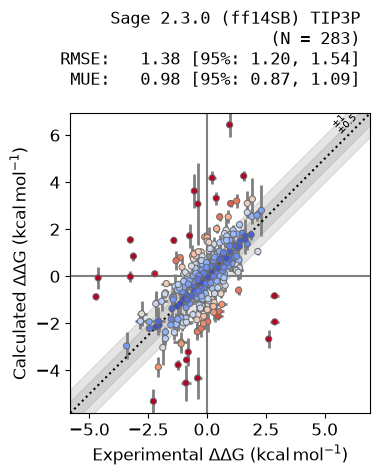

Sage 2.3.0 (ff14SB) TIP3P - RMSE: 1.3777, MUE: 0.9778


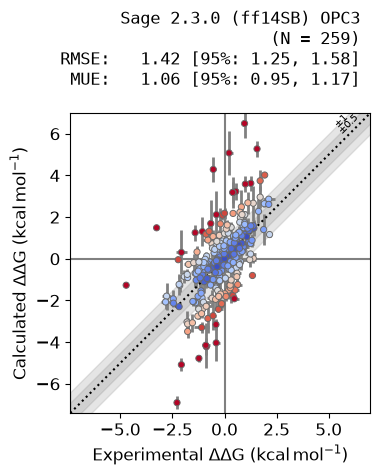

Sage 2.3.0 (ff14SB) OPC3 - RMSE: 1.4219, MUE: 1.0550


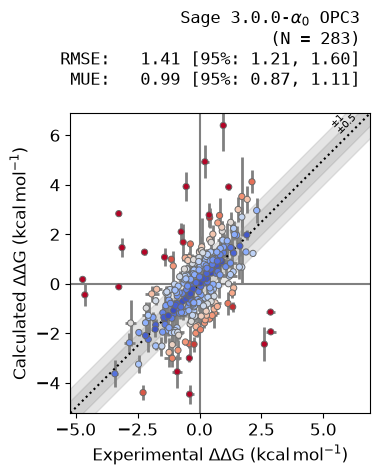

Sage 3.0.0-$\alpha_0$ OPC3 - RMSE: 1.4056, MUE: 0.9871


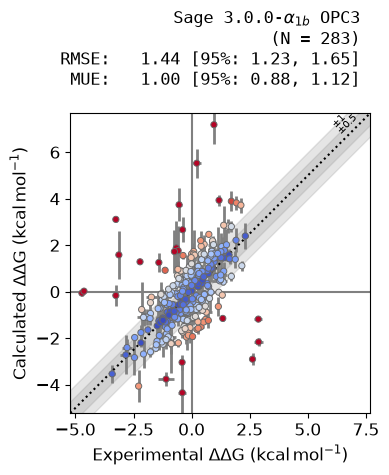

Sage 3.0.0-$\alpha_{1b}$ OPC3 - RMSE: 1.4387, MUE: 1.0033


In [22]:
combined_ddG_list = []
for key, result in results.items():
    femap_list = [ddg for ddg in result.ddg_femaps().values()]
    combined_ddG = sum(femap_list[1:], femap_list[0])
    if key != "Sage 2.3.0 (ff14SB) OPC3":
        combined_ddG_list.append(combined_ddG)
    plotting.plot_DDGs(
        combined_ddG,
        source=key,  # Use the default submission_id
        title=key,
        figsize=5,
        scatter_kwargs={"s": 20, "marker": "o"},
    )
    metrics = get_rmse_for_femap(combined_ddG)
    print(f"{key} - RMSE: {metrics['rmse']:.4f}, MUE: {metrics['mue']:.4f}")

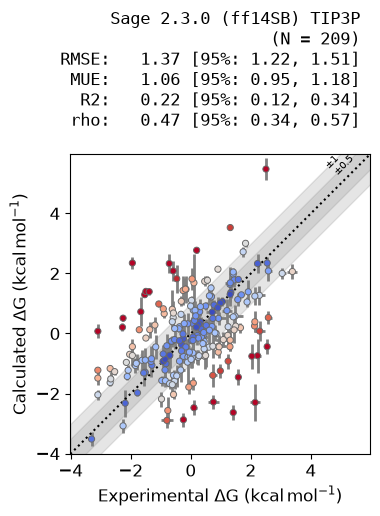

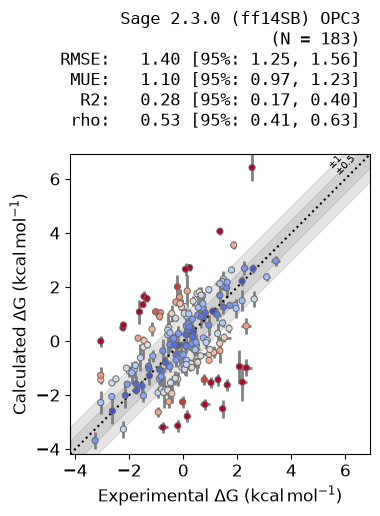

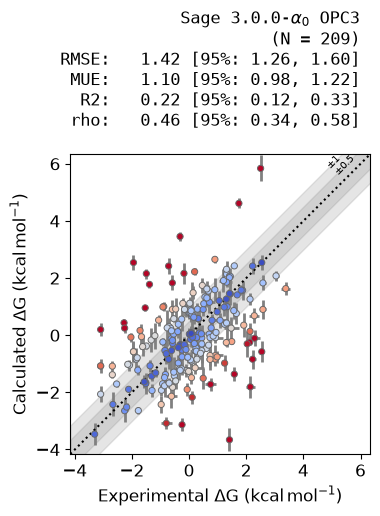

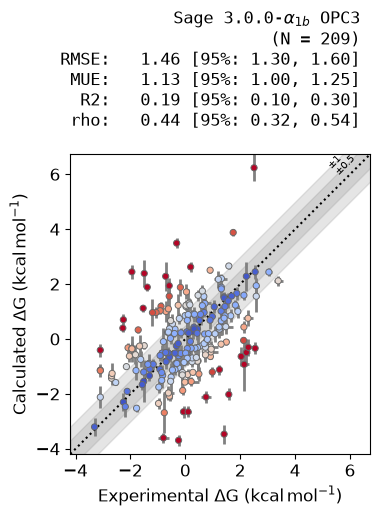

In [23]:
for key, result in results.items():
    femap_list = [dg for dg in result.dg_femaps().values()]
    combined_dG = sum(femap_list[1:], femap_list[0])
    
    plotting.plot_DGs(
        combined_dG,
        source=key,  # Use the default submission_id
        title=key,
        figsize=5,
        scatter_kwargs={"s": 20, "marker": "o"},
    )
    #metrics = get_rmse_for_femap(combined_dG)
    #print(f"{key} - RMSE: {metrics['rmse']:.4f}, MUE: {metrics['mue']:.4f}")

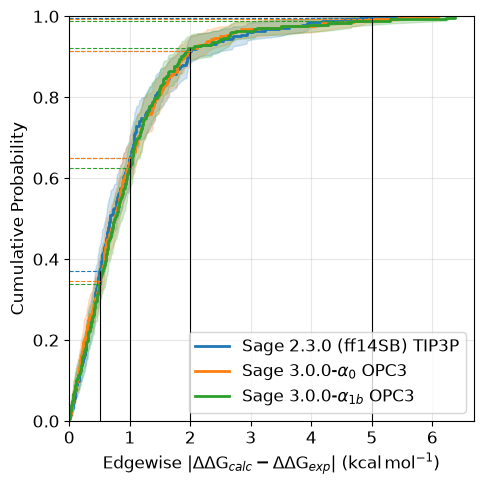

In [24]:
all_ddG = sum(combined_ddG_list[1:], combined_ddG_list[0])
plot_ecdf_with_intercepts(
    all_ddG,
    [0.5, 1.0, 2.0, 5.0],
);

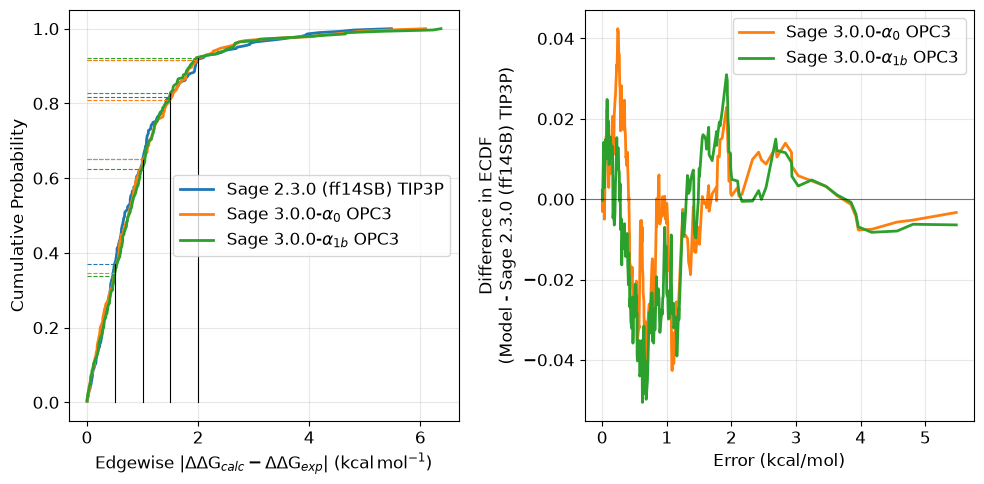

In [25]:
plot_ecdf_with_intercepts_and_difference(all_ddG, x_values, title=None, figsize=5, reference_model="Sage 2.3.0 (ff14SB) TIP3P");

### Plot Comparisons of All Systems

Statistically similar groupings of force fields have the same hatching in their bars

In [9]:
def plot_all_comparisons(summary_dict, title, reference_source=None):
    metric_entries = []
    for system_name, metric_dict in summary_dict.items():
        if not isinstance(metric_dict, dict):
            raise TypeError(
                "Each system entry must be a dict mapping rank_metric to "
                "(summary_df, comparison_df) tuples."
            )

        for rank_metric, value in metric_dict.items():
            if not isinstance(value, tuple) or len(value) != 2:
                raise ValueError(
                    f"Expected (summary_df, comparison_df) tuple for {system_name}/{rank_metric}."
                )

            df, comparison_df = value
            df_copy = df.copy()
            df_copy["system"] = system_name
            df_copy["rank_metric"] = rank_metric

            if reference_source:
                same_as_ref_list = []
                for model in df_copy["Model"]:
                    if model == reference_source:
                        same_as_ref_list.append(True)
                        continue

                    is_significant = False
                    mask1 = (comparison_df["Model 1"] == reference_source) & (comparison_df["Model 2"] == model)
                    if mask1.any():
                        is_significant = comparison_df.loc[mask1, "significant"].iloc[0]
                    else:
                        mask2 = (comparison_df["Model 1"] == model) & (comparison_df["Model 2"] == reference_source)
                        if mask2.any():
                            is_significant = comparison_df.loc[mask2, "significant"].iloc[0]

                    same_as_ref_list.append(not is_significant)

                df_copy["same_as_reference"] = same_as_ref_list
            else:
                df_copy["same_as_reference"] = True

            metric_entries.append(df_copy)

    if not metric_entries:
        raise ValueError("summary_dict did not contain any metric results to plot.")

    combined_df = pd.concat(metric_entries, ignore_index=True)

    unique_models = sorted(combined_df["Model"].unique())
    cinnabar_colors = sns.color_palette(None, n_colors=len(unique_models))
    model_colors = {
        model: color for model, color in zip(unique_models, cinnabar_colors)
    }

    metric_names = list(dict.fromkeys(combined_df["rank_metric"].tolist()))
    fig, axes = plt.subplots(1, len(metric_names), figsize=(7 * len(metric_names), 5))

    if len(metric_names) == 1:
        axes = [axes]

    same_as_ref_hatch_map = {
        True: "",
        False: "///",
    }

    unique_systems = list(summary_dict.keys())
    n_models = len(unique_models)
    width = 0.8 / max(n_models, 1)
    x_positions = np.arange(len(unique_systems))

    for ax, rank_metric in zip(axes, metric_names):
        metric_df = combined_df[combined_df["rank_metric"] == rank_metric].copy()
        value_col = rank_metric
        lower_col = f"{rank_metric}_CI_Lower"
        upper_col = f"{rank_metric}_CI_Upper"

        missing_columns = [
            column
            for column in (value_col, lower_col, upper_col)
            if column not in metric_df.columns
        ]
        if missing_columns:
            raise KeyError(
                f"Missing expected columns for {rank_metric}: {missing_columns}"
            )

        for model_idx, model in enumerate(unique_models):
            model_data = metric_df[metric_df["Model"] == model]

            for _, row in model_data.iterrows():
                system_name = row["system"]
                system_pos = unique_systems.index(system_name)
                x_pos = system_pos + (model_idx - n_models / 2 + 0.5) * width

                ax.bar(
                    x_pos,
                    row[value_col],
                    width,
                    yerr=[
                        [row[value_col] - row[lower_col]],
                        [row[upper_col] - row[value_col]],
                    ],
                    color=model_colors[model],
                    hatch=same_as_ref_hatch_map.get(row["same_as_reference"], "///"),
                    capsize=3,
                    error_kw={"elinewidth": 1.5},
                )

        ax.set_title(rank_metric)
        ax.set_ylabel(rank_metric)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(unique_systems, rotation=45, ha="right")
        ax.set_ylim(bottom=0)
        ax.grid(axis="y", alpha=0.3)

    model_patches = [
        Patch(facecolor=model_colors[model], label=model) for model in unique_models
    ]
    if reference_source:
        model_patches.append(
            Patch(facecolor="white", edgecolor="black", hatch="///", label=f"Different from {reference_source}")
        )
        model_patches.append(
            Patch(facecolor="white", edgecolor="black", label=f"Not different from {reference_source}")
        )

    fig.legend(
        handles=model_patches,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.05),
        ncol=max(1, min(len(model_patches), len(unique_models) + 2)),
    )

    fig.suptitle(title, fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
    plt.close()

<>:29: SyntaxWarning: invalid escape sequence '\D'
<>:29: SyntaxWarning: invalid escape sequence '\D'
/var/folders/dr/9nnhm1493kv7_s9r_wj_l_jm0000gn/T/ipykernel_2349/3744840897.py:29: SyntaxWarning: invalid escape sequence '\D'
  plot_all_comparisons(comparison_results, "JACS Set: $\Delta\Delta G$", reference_source="Sage 2.3.0 (ff14SB) TIP3P")


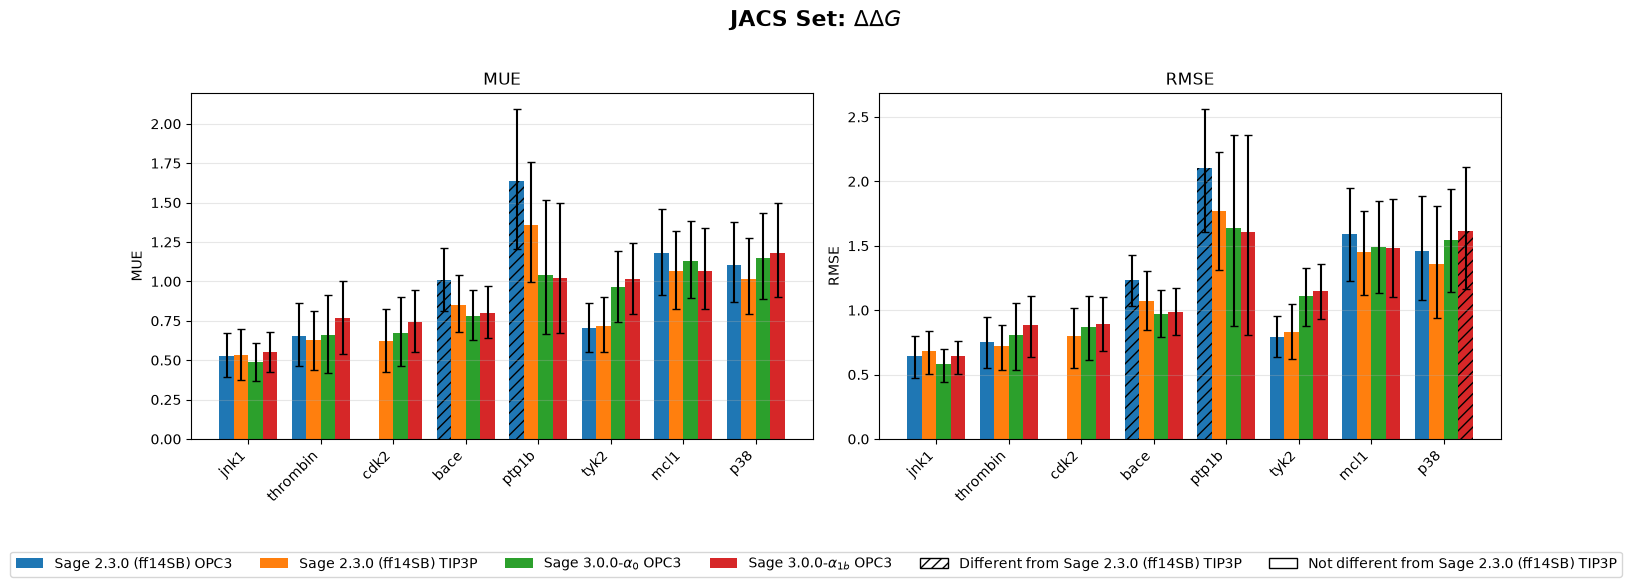

In [10]:
system_keys = next(iter(results.values())).ddg_femaps().keys()
comparison_results = defaultdict(dict)
for system_group_name in system_keys:
    femap_list = [result.ddg_femaps()[system_group_name] for result in results.values() if system_group_name in result.ddg_femaps()]
    combined_femap = sum(femap_list[1:], femap_list[0])

    summary_df, comparison_df = compare_and_rank_results(
        femap=combined_femap,
        prediction_type="edgewise",
        rank_metric="MUE",  # the metric used for ranking the results
        metrics_to_compute=["MUE"],  # metrics to report in the summary table
        num_bootstraps=10_000,
        confidence_level=0.95,  # report 95 % confidence intervals
        alpha=0.05,  # for statistical significance testing (e.g. p-value threshold)
    )
    comparison_results[system_group_name[1]]["MUE"] = (summary_df, comparison_df)

    summary_df, comparison_df = compare_and_rank_results(
        femap=combined_femap,
        prediction_type="edgewise",
        rank_metric="RMSE",  # the metric used for ranking the results
        metrics_to_compute=["RMSE"],  # metrics to report in the summary table
        num_bootstraps=10_000,
        confidence_level=0.95,  # report 95 % confidence intervals
        alpha=0.05,  # for statistical significance testing (e.g. p-value threshold)
    )
    comparison_results[system_group_name[1]]["RMSE"] = (summary_df, comparison_df)

plot_all_comparisons(comparison_results, "JACS Set: $\Delta\Delta G$", reference_source="Sage 2.3.0 (ff14SB) TIP3P")

## Get dG Comparisons

In [7]:
for key, result in results.items():
    result.dg_femaps(source=key, force_source_update=True)

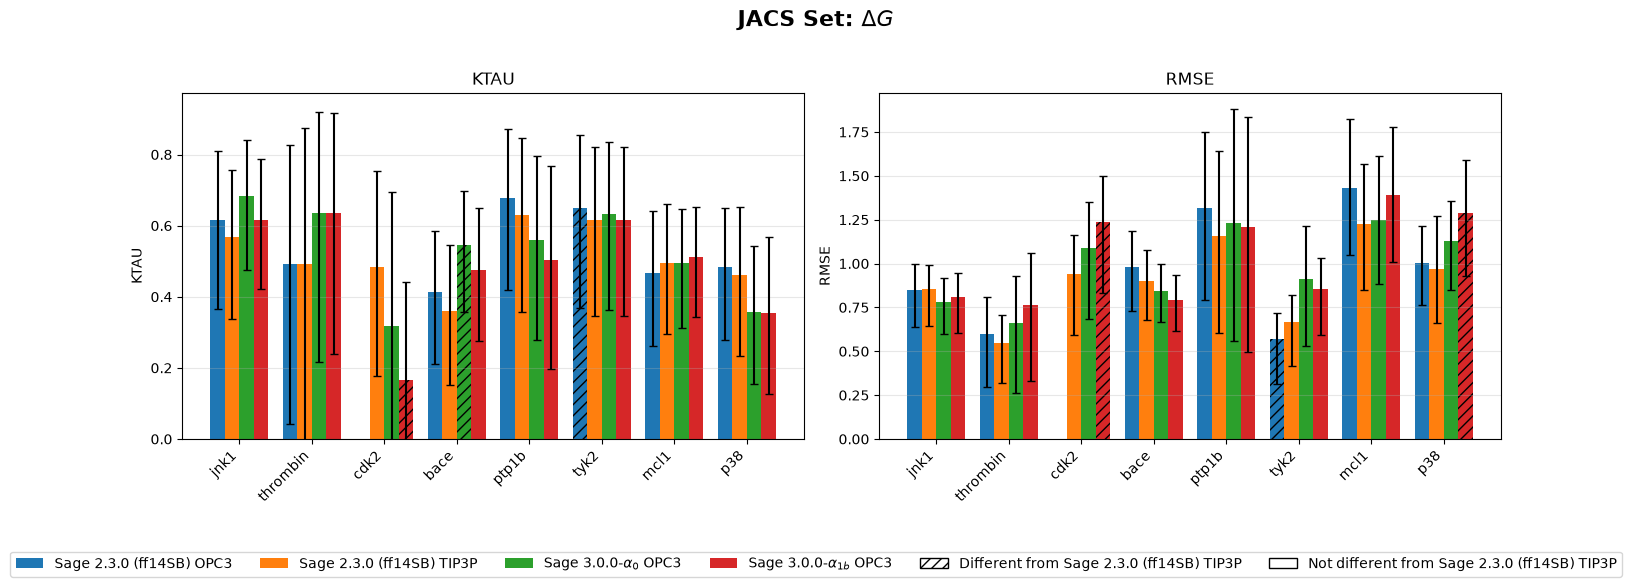

In [18]:
system_keys = next(iter(results.values())).ddg_femaps().keys()
comparison_results = defaultdict(dict)
for system_group_name in system_keys:
    femap_list = [
        result.dg_femaps(source=key)[system_group_name]
        for key, result in results.items() if system_group_name in result.dg_femaps(source=key)
    ]
    combined_femap = sum(femap_list[1:], femap_list[0])

    summary_df, comparison_df = compare_and_rank_results(
        femap=combined_femap,
        prediction_type="nodewise",
        rank_metric="KTAU",  # the metric used for ranking the results
        metrics_to_compute=["KTAU"],  # metrics to report in the summary table
        num_bootstraps=10_000,
        confidence_level=0.95,  # report 95 % confidence intervals
        alpha=0.05,  # for statistical significance testing (e.g. p-value threshold)
    )
    comparison_results[system_group_name[1]]["KTAU"] = (summary_df, comparison_df)

    summary_df, comparison_df = compare_and_rank_results(
        femap=combined_femap,
        prediction_type="nodewise",
        rank_metric="RMSE",  # the metric used for ranking the results
        metrics_to_compute=["RMSE"],  # metrics to report in the summary table
        num_bootstraps=10_000,
        confidence_level=0.95,  # report 95 % confidence intervals
        alpha=0.05,  # for statistical significance testing (e.g. p-value threshold)
    )
    comparison_results[system_group_name[1]]["RMSE"] = (summary_df, comparison_df)

plot_all_comparisons(comparison_results, "JACS Set: $\\Delta G$", reference_source="Sage 2.3.0 (ff14SB) TIP3P")

def compare_and_rank_results(
    femap: FEMap,
    prediction_type: Literal["nodewise", "edgewise"] = "edgewise",
    rank_metric: Literal["MUE", "RMSE", "RAE", "R2", "rho", "KTAU", "PI"] = "MUE",
    metrics_to_compute: list[Literal["MUE", "RMSE", "RAE", "R2", "rho", "KTAU", "PI"]] | None = None,
    num_bootstraps: int = 1_000,
    confidence_level: float = 0.95,
    alpha: float = 0.05,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Compare and rank multiple result sources on a single FEMap based on the chosen performance metric and return an ordered table of
    results using the compact letter display (CLD) system.

    Parameters
    ----------
    femap : FEMap
        An FEMap instance with results from multiple sources to compare.
    prediction_type: {"nodewise", "edgewise"}, default "edgewise"
        The type of prediction in the FEMap to evaluate.
    rank_metric : {"MUE", "RMSE", "RAE", "R2", "rho", "KTAU", "PI"}, default "MUE"
        The metric used to rank the mo